**Practical No 1: Implement a basic neural network using tensorflow**

What is a Neural Network? (

A Neural Network (NN) is a machine learning model inspired by the human brain.

It consists of neurons (nodes) arranged in layers.


Basic Structure


Input Layer → Hidden Layer(s) → Output Layer

How it works

1. Input layer receives data (features)

2. Hidden layers apply:

      - weights

      - bias

      - activation function

3. Output layer gives prediction

4. Loss function measures error

5. Optimizer adjusts weights using backpropagation

Mathematical idea of a neuron

output = activation( w1*x1 + w2*x2 + ... + bias )


What is TensorFlow?

TensorFlow is an open-source deep learning framework by Google.

Why TensorFlow?

  - Easy to build neural networks

  - Supports CPU & GPU

  - Scales from simple models to large systems

  - Uses Keras API for simplicity


We will use TensorFlow + Keras

Problem Statement (Practical)

👉 Task:
Build a simple neural network to classify handwritten digits (0–9) using the MNIST dataset.

Input: 28×28 grayscale images

Output: Digit class (0–9)

Step-by-Step Implementation

Step 1: Install & Import Libraries

In [13]:
!pip install tensorflow

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


Step 2: Load Dataset (MNIST)

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
# Dataset shape
print(x_train.shape)  # (60000, 28, 28)
print(y_train.shape)  # (60000,)


(60000, 28, 28)
(60000,)


Step 3: Data Preprocessing

Neural networks work better when data is normalized.

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0


Step 4: Build a Basic Neural Network

In [6]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),   # Convert 2D → 1D
    layers.Dense(128, activation='relu'),   # Hidden layer
    layers.Dense(10, activation='softmax')  # Output layer
])

C:\Users\Abdul Shaikh\Documents\Anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


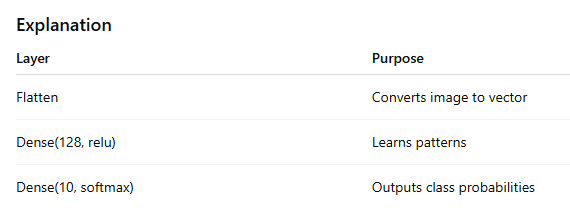

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Step 5: Compile the Model

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Key terms

Adam → Optimizer

Loss function → Measures error

Accuracy → Performance metric

Step 6: Train the Neural Network

In [9]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9220 - loss: 0.2748 - val_accuracy: 0.9622 - val_loss: 0.1354
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9646 - loss: 0.1205 - val_accuracy: 0.9700 - val_loss: 0.1072
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9751 - loss: 0.0830 - val_accuracy: 0.9755 - val_loss: 0.0810
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9807 - loss: 0.0626 - val_accuracy: 0.9765 - val_loss: 0.0809
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9858 - loss: 0.0472 - val_accuracy: 0.9785 - val_loss: 0.0782


Step 7: Evaluate the Model

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9779 - loss: 0.0765
Test Accuracy: 0.9779000282287598


Step 8: Make Predictions

In [11]:
predictions = model.predict(x_test)

print("Predicted digit:", predictions[0].argmax())
print("Actual digit:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Predicted digit: 7
Actual digit: 7


Step 9: Visualize a Prediction

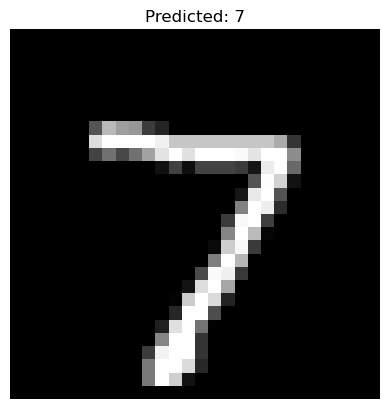

In [12]:
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predictions[0].argmax()}")
plt.axis('off')
plt.show()


Key Takeaways

✔ Neural networks learn patterns using layers

✔ TensorFlow simplifies deep learning

✔ Keras allows quick model building

✔ MNIST is ideal for beginners